In [1]:
# install needed images
!python -m pip install paddlepaddle
!pip install "paddleocr>=2.0.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.8/297.8 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.1 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=527eb05214b5ffce408cdaae91f8792134088503816fd973ffd9dc64fb340185
  Stored 

In [2]:
from paddleocr import PaddleOCR,draw_ocr
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

/usr/local/lib/python3.11/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


In [3]:
plt.rcParams['figure.figsize']=[15,10]

In [4]:
##  Load the model

ocr=PaddleOCR(use_angle_cls=True,lang='en')

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:16<00:00, 235.62it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:18<00:00, 534.85it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:15<00:00, 138.41it/s]

[2025/04/14 10:43:57] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

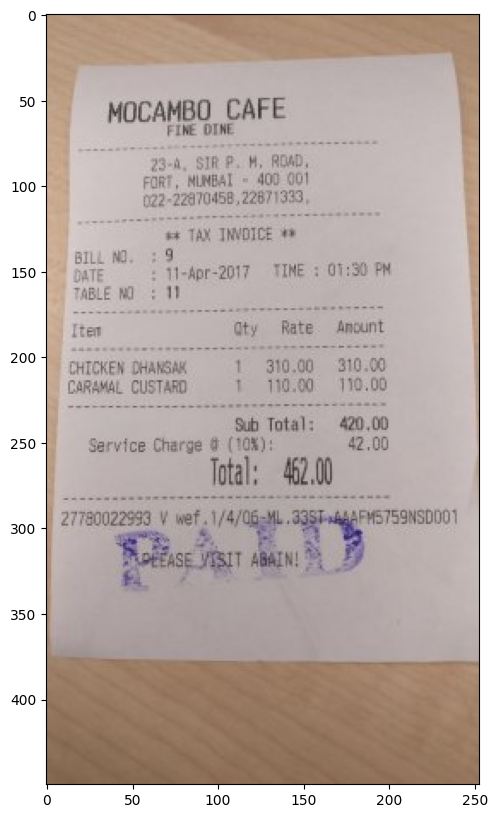

In [5]:
img_path="/content/finally-the-bill.jpg"
image=Image.open(img_path).convert('RGB')
plt.imshow(image)

In [6]:
### Load the image opencv2

img=cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
#3 apply model on the image
result=ocr.ocr(img, cls=True)
for line in result:
  print(line)

[2025/04/14 10:47:48] ppocr DEBUG: dt_boxes num : 32, elapsed : 0.14122891426086426
[2025/04/14 10:47:48] ppocr DEBUG: cls num  : 32, elapsed : 0.18299651145935059
[2025/04/14 10:47:50] ppocr DEBUG: rec_res num  : 32, elapsed : 2.0287187099456787
[[[[34.0, 48.0], [141.0, 45.0], [142.0, 62.0], [35.0, 65.0]], ('MOCAMBO CAFE', 0.9655299186706543)], [[[69.0, 62.0], [112.0, 62.0], [112.0, 72.0], [69.0, 72.0]], ('FINE DINE', 0.9514206647872925)], [[[57.0, 80.0], [154.0, 78.0], [154.0, 91.0], [58.0, 94.0]], ('23-A.SIRP.H.ROAD', 0.8258159160614014)], [[[54.0, 91.0], [155.0, 87.0], [155.0, 101.0], [55.0, 105.0]], ('FORTMLMBAI-400001', 0.8065641522407532)], [[[54.0, 102.0], [154.0, 99.0], [154.0, 113.0], [55.0, 116.0]], ('022-22870458,22871333,', 0.9135256409645081)], [[[67.0, 123.0], [146.0, 121.0], [146.0, 133.0], [67.0, 134.0]], ('TAX INVDICE ', 0.7941482663154602)], [[[13.0, 136.0], [78.0, 132.0], [78.0, 146.0], [13.0, 150.0]], ('BILL NO.9', 0.8400218486785889)], [[[16.0, 149.0], [37.0, 149.

In [7]:
### Load the image opencv2

img=cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
#3 apply model on the image
result=ocr.ocr(img_path, cls=True)
for line in result:
  print(line)

[2025/04/14 10:48:08] ppocr DEBUG: dt_boxes num : 32, elapsed : 0.05908489227294922
[2025/04/14 10:48:08] ppocr DEBUG: cls num  : 32, elapsed : 0.07986950874328613
[2025/04/14 10:48:09] ppocr DEBUG: rec_res num  : 32, elapsed : 1.6161518096923828
[[[[34.0, 48.0], [141.0, 45.0], [142.0, 62.0], [35.0, 65.0]], ('MOCAMBO CAFE', 0.9655299186706543)], [[[69.0, 62.0], [112.0, 62.0], [112.0, 72.0], [69.0, 72.0]], ('FINE DINE', 0.9514206647872925)], [[[57.0, 80.0], [154.0, 78.0], [154.0, 91.0], [58.0, 94.0]], ('23-A.SIRP.H.ROAD', 0.8258159160614014)], [[[54.0, 91.0], [155.0, 87.0], [155.0, 101.0], [55.0, 105.0]], ('FORTMLMBAI-400001', 0.8065641522407532)], [[[54.0, 102.0], [154.0, 99.0], [154.0, 113.0], [55.0, 116.0]], ('022-22870458,22871333,', 0.9135256409645081)], [[[67.0, 123.0], [146.0, 121.0], [146.0, 133.0], [67.0, 134.0]], ('TAX INVDICE ', 0.7941482663154602)], [[[13.0, 136.0], [78.0, 132.0], [78.0, 146.0], [13.0, 150.0]], ('BILL NO.9', 0.8400218486785889)], [[[16.0, 149.0], [37.0, 149.

In [17]:
result = ocr.ocr(img, cls=True)[0]  # Not just result = ocr.ocr(img, cls=True)
result

[2025/04/14 11:11:51] ppocr DEBUG: dt_boxes num : 32, elapsed : 0.060662031173706055
[2025/04/14 11:11:51] ppocr DEBUG: cls num  : 32, elapsed : 0.09758949279785156
[2025/04/14 11:11:53] ppocr DEBUG: rec_res num  : 32, elapsed : 1.5116140842437744


[[[[34.0, 48.0], [141.0, 45.0], [142.0, 62.0], [35.0, 65.0]],
  ('MOCAMBO CAFE', 0.9655299186706543)],
 [[[69.0, 62.0], [112.0, 62.0], [112.0, 72.0], [69.0, 72.0]],
  ('FINE DINE', 0.9514206647872925)],
 [[[57.0, 80.0], [154.0, 78.0], [154.0, 91.0], [58.0, 94.0]],
  ('23-A.SIRP.H.ROAD', 0.8258159160614014)],
 [[[54.0, 91.0], [155.0, 87.0], [155.0, 101.0], [55.0, 105.0]],
  ('FORTMLMBAI-400001', 0.8065641522407532)],
 [[[54.0, 102.0], [154.0, 99.0], [154.0, 113.0], [55.0, 116.0]],
  ('022-22870458,22871333,', 0.9135256409645081)],
 [[[67.0, 123.0], [146.0, 121.0], [146.0, 133.0], [67.0, 134.0]],
  ('TAX INVDICE ', 0.7941482663154602)],
 [[[13.0, 136.0], [78.0, 132.0], [78.0, 146.0], [13.0, 150.0]],
  ('BILL NO.9', 0.8400218486785889)],
 [[[16.0, 149.0], [37.0, 149.0], [37.0, 157.0], [16.0, 157.0]],
  ('DATE', 0.9753962755203247)],
 [[[58.0, 145.0], [123.0, 145.0], [123.0, 156.0], [58.0, 156.0]],
  ('11-Apr-2017', 0.9819377660751343)],
 [[[127.0, 144.0], [202.0, 144.0], [202.0, 155.0], [

In [19]:
# draw result
image = Image.open(img_path).convert('RGB')

In [25]:
# Check the structure of 'result' first
boxes = [line[0] for line in result]
txts = [line[1][0] for line in result]
scores = [line[1][1] for line in result if isinstance(line[1][1], (int, float))]  # Ensure it's a number

# If there are still issues, print the result to inspect the structure
print(result)


[[[[34.0, 48.0], [141.0, 45.0], [142.0, 62.0], [35.0, 65.0]], ('MOCAMBO CAFE', 0.9655299186706543)], [[[69.0, 62.0], [112.0, 62.0], [112.0, 72.0], [69.0, 72.0]], ('FINE DINE', 0.9514206647872925)], [[[57.0, 80.0], [154.0, 78.0], [154.0, 91.0], [58.0, 94.0]], ('23-A.SIRP.H.ROAD', 0.8258159160614014)], [[[54.0, 91.0], [155.0, 87.0], [155.0, 101.0], [55.0, 105.0]], ('FORTMLMBAI-400001', 0.8065641522407532)], [[[54.0, 102.0], [154.0, 99.0], [154.0, 113.0], [55.0, 116.0]], ('022-22870458,22871333,', 0.9135256409645081)], [[[67.0, 123.0], [146.0, 121.0], [146.0, 133.0], [67.0, 134.0]], ('TAX INVDICE ', 0.7941482663154602)], [[[13.0, 136.0], [78.0, 132.0], [78.0, 146.0], [13.0, 150.0]], ('BILL NO.9', 0.8400218486785889)], [[[16.0, 149.0], [37.0, 149.0], [37.0, 157.0], [16.0, 157.0]], ('DATE', 0.9753962755203247)], [[[58.0, 145.0], [123.0, 145.0], [123.0, 156.0], [58.0, 156.0]], ('11-Apr-2017', 0.9819377660751343)], [[[127.0, 144.0], [202.0, 144.0], [202.0, 155.0], [127.0, 155.0]], ('TIME01:30

In [29]:
from google.colab import files
uploaded = files.upload()  # This will prompt you to upload the font file


Saving OpenSans_Condensed-Bold.ttf to OpenSans_Condensed-Bold (1).ttf


0.9655299186706543
0.9514206647872925
0.8258159160614014
0.8065641522407532
0.9135256409645081
0.7941482663154602
0.8400218486785889
0.9753962755203247
0.9819377660751343
0.8890592455863953
0.8665118217468262
0.9577339887619019
0.9540226459503174
0.9950721859931946
0.9846556782722473
0.9676756262779236
0.6550268530845642
0.995067298412323
0.9903448224067688
0.9532654881477356
0.9914293885231018
0.9895328879356384
0.899695873260498
0.9837567210197449
0.9334363341331482
0.9907973408699036
0.9526057243347168
0.8996952772140503
0.9837665557861328
0.6889708638191223


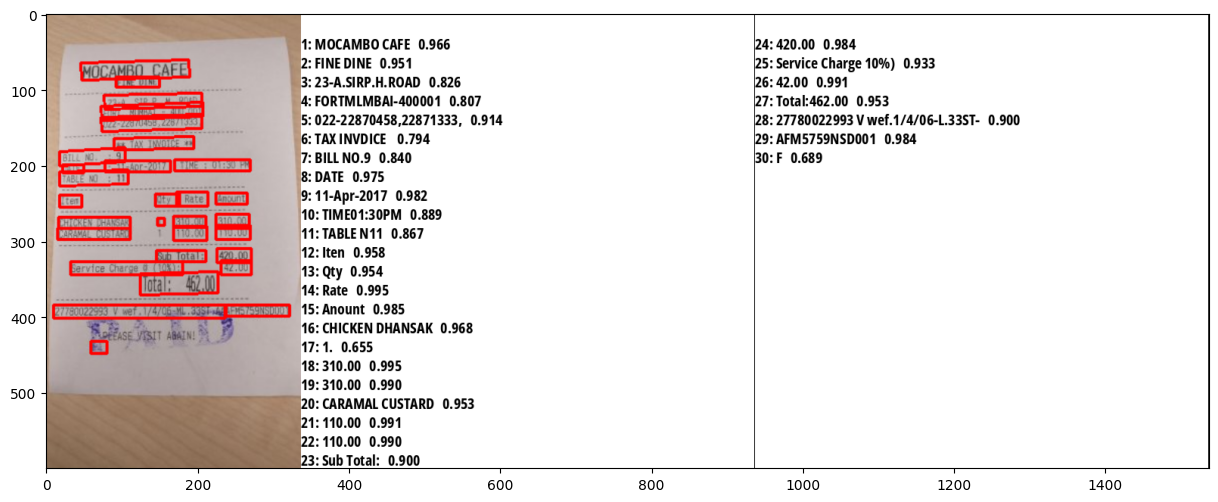

In [30]:
# Check the contents of result to ensure correct extraction of scores
for line in result:
    print(line[1][1])  # Print each score to check its type

# Ensure all scores are converted to floats and that no non-numeric strings remain
scores = []
for line in result:
    try:
        score = float(line[1][1])  # Try to convert each score to float
        scores.append(score)
    except ValueError:
        print(f"Invalid score value: {line[1][1]}")  # Print problematic score if it's not convertible

# Set a valid drop_score value (if you don't want to filter, you can set it to 0.0)
drop_score = 0.0

# Now draw the OCR results
im_show = draw_ocr(image, boxes, txts, scores, drop_score=drop_score, font_path="/content/OpenSans_Condensed-Bold.ttf")
im_show = Image.fromarray(im_show)
plt.imshow(im_show)

